<a href="https://colab.research.google.com/github/jrebull/MIAAD_IngenieraDatos/blob/main/Semana09_PySpark_Titanic_JavierRebull.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Link GitHub: https://github.com/jrebull/MIAAD_IngenieraDatos/blob/main/Semana09_PySpark_Titanic_JavierRebull.ipynb

<div style="background:#2c2c2c; display:inline-block; padding:12px 20px; border-radius:8px;">
  <img src="https://www.uacj.mx/images/UACJ-LOGO.png" width="700"/>
</div>

# **PySpark: Operaciones Básicas con DataFrames — Dataset Titanic**

---

**Programa:** Maestría en Inteligencia Artificial y Analítica de Datos  
**Materia:** Ingeniería de Datos Avanzada  
**Profesor:** Dr. Vicente García Jiménez  
**Estudiante:** Javier Augusto Rebull Saucedo  
**Matrícula:** 263483  
**Semana:** 09  
**Fecha:** Marzo 29, 2026  

---

## Marco Teórico

### Apache Spark y Spark SQL

**Apache Spark** es un motor de procesamiento de datos distribuido de propósito general, diseñado para operar sobre grandes volúmenes de datos en clústeres de computadoras. A diferencia de Hadoop MapReduce, Spark ejecuta operaciones en memoria (*in-memory*), lo que resulta en velocidades de procesamiento hasta 100 veces superiores para ciertas cargas de trabajo (Zaharia et al., 2016).

**Spark SQL** es el módulo de Spark para el procesamiento de datos estructurados y semiestructurados. Su principal aportación es el concepto de *esquema*: al imponer una estructura tipada sobre los datos, Spark puede construir un plan lógico de ejecución y optimizarlo mediante el **Catalyst Optimizer** antes de ejecutar cualquier operación (Armbrust et al., 2015).

### DataFrames en PySpark

Un **DataFrame** es una colección distribuida de datos organizada en columnas con nombre y tipo definido, conceptualmente equivalente a una tabla relacional o a un DataFrame de pandas. Sus características principales son:

- **Inmutabilidad**: toda operación genera un nuevo DataFrame; el original nunca se modifica.
- **Evaluación perezosa (*lazy evaluation*)**: las transformaciones se acumulan en un *plan de ejecución* y solo se materializan cuando se llama una *acción* (como `show()`, `count()` o `collect()`).
- **Optimización automática**: el Catalyst Optimizer reorganiza y simplifica el plan lógico antes de ejecutarlo, independientemente del lenguaje utilizado.

### Dataset Titanic

El dataset Titanic es uno de los conjuntos de datos de referencia más utilizados en ciencia de datos. Contiene información sobre los 891 pasajeros registrados en el naufragio del RMS Titanic (abril de 1912), incluyendo variables sociodemográficas, clase de viaje y estado de supervivencia. Es ampliamente utilizado para explorar análisis descriptivo, imputación de valores nulos y modelado predictivo (Kaggle, 2012).

<img src="https://offloadmedia.feverup.com/secretlosangeles.com/wp-content/uploads/2023/01/13025008/shutterstock_1837038775-1-1024x671.jpg" width="700"/>

---
## Bloque 0. Instalación y Configuración

In [1]:
# ── Instalar PySpark solo si no está disponible ──────────────────────────────
try:
    import pyspark
    print(f"PySpark ya instalado — versión {pyspark.__version__}")
except ModuleNotFoundError:
    print("Instalando PySpark...")
    import subprocess
    subprocess.run(["pip", "install", "pyspark", "-q"], check=True)
    import pyspark
    print(f"Instalación completa — versión {pyspark.__version__}")

PySpark ya instalado — versión 4.0.2


In [2]:
# ── Importaciones globales ───────────────────────────────────────────────────
from pyspark.sql import SparkSession, Row
from pyspark.sql import functions as F
from pyspark.sql.functions import col, isnan, when, count, sum as spark_sum
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    DoubleType, FloatType
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import warnings

warnings.filterwarnings('ignore')
print("Importaciones completadas.")

Importaciones completadas.


In [3]:
# ── Crear SparkSession con patrón Builder ────────────────────────────────────
# local[*] utiliza todos los núcleos disponibles de la VM de Colab
spark = (
    SparkSession.builder
    .appName("Semana09-Titanic-DataFrames")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")      # óptimo para datasets pequeños
    .config("spark.sql.adaptive.enabled", "true")     # AQE: ajuste dinámico del plan
    .getOrCreate()
)

# Reducir verbosidad de logs para mayor legibilidad
spark.sparkContext.setLogLevel("ERROR")

print("=" * 55)
print("  SparkSession inicializada correctamente")
print("=" * 55)
print(f"  Version Spark    : {spark.version}")
print(f"  Nombre app       : {spark.sparkContext.appName}")
print(f"  Master           : {spark.sparkContext.master}")
print(f"  Cores disponibles: {spark.sparkContext.defaultParallelism}")

  SparkSession inicializada correctamente
  Version Spark    : 4.0.2
  Nombre app       : Semana09-Titanic-DataFrames
  Master           : local[*]
  Cores disponibles: 2


---
## Bloque 1. Carga de Datos

El punto de entrada para leer datos estructurados en PySpark es `spark.read`, que devuelve un **DataFrameReader**
capaz de consumir múltiples formatos (CSV, JSON, Parquet, JDBC, entre otros).

Para archivos CSV se recomienda definir el esquema manualmente mediante `StructType` en lugar de usar
`inferSchema=True`. La inferencia automática obliga a Spark a realizar **dos barridos** del archivo:
el primero para deducir tipos y el segundo para cargar los datos, lo que duplica el costo de lectura
innecesariamente. Un esquema explícito también garantiza tipos correctos y evita que columnas numéricas
sean interpretadas como `StringType` cuando existen valores nulos.

La opción `nullValue=""` instruye a Spark a tratar las celdas vacías del CSV como `null` nativo,
lo que permite usar `isNull()` de forma confiable en etapas posteriores de análisis.

In [4]:
# ── Descargar el dataset desde Google Drive con gdown ────────────────────────
# gdown permite descargar archivos de Drive directamente a Colab
import subprocess

result = subprocess.run(
    ["pip", "install", "gdown", "-q"],
    capture_output=True, text=True
)

import gdown

FILE_ID  = "1epidGM3utB0WCCI5fvAg02hkiSebwoE9"
FILE_URL = f"https://drive.google.com/uc?id={FILE_ID}"
OUTPUT   = "Titanic-Dataset.csv"

gdown.download(FILE_URL, OUTPUT, quiet=False)
print(f"Dataset descargado: {OUTPUT}")

Downloading...
From: https://drive.google.com/uc?id=1epidGM3utB0WCCI5fvAg02hkiSebwoE9
To: /content/Titanic-Dataset.csv
100%|██████████| 61.2k/61.2k [00:00<00:00, 30.0MB/s]

Dataset descargado: Titanic-Dataset.csv


In [5]:
# ── Definir esquema explícito (mejor práctica que inferSchema=True) ───────────
# Definir el esquema evita un segundo barrido del archivo y garantiza tipos correctos
TITANIC_SCHEMA = StructType([
    StructField("PassengerId", IntegerType(), True),
    StructField("Survived",    IntegerType(), True),
    StructField("Pclass",      IntegerType(), True),
    StructField("Name",        StringType(),  True),
    StructField("Sex",         StringType(),  True),
    StructField("Age",         DoubleType(),  True),
    StructField("SibSp",       IntegerType(), True),
    StructField("Parch",       IntegerType(), True),
    StructField("Ticket",      StringType(),  True),
    StructField("Fare",        DoubleType(),  True),
    StructField("Cabin",       StringType(),  True),
    StructField("Embarked",    StringType(),  True),
])

# ── Cargar CSV con Spark ──────────────────────────────────────────────────────
# header=True: usa la primera fila como nombres de columnas
# schema=TITANIC_SCHEMA: aplica el esquema definido manualmente
df = (
    spark.read
    .option("header", "true")
    .option("nullValue", "")
    .csv(OUTPUT, schema=TITANIC_SCHEMA)
)

print("DataFrame cargado exitosamente.")
print(f"Dimensiones: {df.count():,} filas x {len(df.columns)} columnas")

DataFrame cargado exitosamente.
Dimensiones: 891 filas x 12 columnas


---
## Bloque 2. Exploración Inicial

Antes de cualquier transformación, es fundamental entender la estructura y el contenido del DataFrame.
`printSchema()` revela el árbol de tipos inferidos, mientras que `show()` materializa las primeras filas
ejecutando el plan lazy acumulado hasta ese punto. Ambas son **acciones** — es decir, disparan la ejecución
real en el clúster.

In [6]:
# ── show(): visualizar las primeras filas del DataFrame ──────────────────────
# show() es una ACCION — dispara la ejecucion del plan lazy
# truncate=False muestra el contenido completo de cada celda
print("Primeras 5 filas del dataset:")
df.show(5, truncate=False)

Primeras 5 filas del dataset:
+-----------+--------+------+---------------------------------------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|Name                                               |Sex   |Age |SibSp|Parch|Ticket          |Fare   |Cabin|Embarked|
+-----------+--------+------+---------------------------------------------------+------+----+-----+-----+----------------+-------+-----+--------+
|1          |0       |3     |Braund, Mr. Owen Harris                            |male  |22.0|1    |0    |A/5 21171       |7.25   |NULL |S       |
|2          |1       |1     |Cumings, Mrs. John Bradley (Florence Briggs Thayer)|female|38.0|1    |0    |PC 17599        |71.2833|C85  |C       |
|3          |1       |3     |Heikkinen, Miss. Laina                             |female|26.0|0    |0    |STON/O2. 3101282|7.925  |NULL |S       |
|4          |1       |1     |Futrelle, Mrs. Jacques Heath (Lily May Peel)       |female|35.0|1

In [7]:
# ── printSchema(): visualizar la estructura de tipos del DataFrame ────────────
# Muestra el arbol de tipos — esencial para detectar columnas mal tipadas
print("Esquema del DataFrame:")
df.printSchema()

Esquema del DataFrame:
root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)



In [8]:
# ── Inspección general del DataFrame ─────────────────────────────────────────
n_filas = df.count()
n_cols  = len(df.columns)

print("=" * 55)
print("  INSPECCION GENERAL")
print("=" * 55)
print(f"  Filas     : {n_filas:,}")
print(f"  Columnas  : {n_cols}")
print(f"  Columnas  : {df.columns}")

# Vista vertical de la primera fila — util cuando hay muchas columnas
print("\nPrimera fila en formato vertical:")
df.show(1, truncate=False, vertical=True)

  INSPECCION GENERAL
  Filas     : 891
  Columnas  : 12
  Columnas  : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Primera fila en formato vertical:
-RECORD 0------------------------------
 PassengerId | 1                       
 Survived    | 0                       
 Pclass      | 3                       
 Name        | Braund, Mr. Owen Harris 
 Sex         | male                    
 Age         | 22.0                    
 SibSp       | 1                       
 Parch       | 0                       
 Ticket      | A/5 21171               
 Fare        | 7.25                    
 Cabin       | NULL                    
 Embarked    | S                       
only showing top 1 row


---
## Bloque 3. Selección de Columnas

`select()` es una **transformación** que proyecta un subconjunto de columnas sobre el DataFrame original,
devolviendo un nuevo DataFrame sin modificar el primero. Al ser lazy, no ejecuta nada hasta que
una acción lo demande. Es el equivalente directo del `SELECT` en SQL.

In [9]:
# ── select(): proyeccion de columnas ─────────────────────────────────────────
# Devuelve un NUEVO DataFrame solo con las columnas especificadas
# No modifica el DataFrame original (principio de inmutabilidad)
COLUMNAS_SELECCIONADAS = ["Name", "Age", "Sex"]

df_seleccion = df.select(COLUMNAS_SELECCIONADAS)

print(f"Seleccion de columnas: {COLUMNAS_SELECCIONADAS}")
df_seleccion.show(10, truncate=False)

Seleccion de columnas: ['Name', 'Age', 'Sex']
+---------------------------------------------------+----+------+
|Name                                               |Age |Sex   |
+---------------------------------------------------+----+------+
|Braund, Mr. Owen Harris                            |22.0|male  |
|Cumings, Mrs. John Bradley (Florence Briggs Thayer)|38.0|female|
|Heikkinen, Miss. Laina                             |26.0|female|
|Futrelle, Mrs. Jacques Heath (Lily May Peel)       |35.0|female|
|Allen, Mr. William Henry                           |35.0|male  |
|Moran, Mr. James                                   |NULL|male  |
|McCarthy, Mr. Timothy J                            |54.0|male  |
|Palsson, Master. Gosta Leonard                     |2.0 |male  |
|Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)  |27.0|female|
|Nasser, Mrs. Nicholas (Adele Achem)                |14.0|female|
+---------------------------------------------------+----+------+
only showing top 10 rows


---
## Bloque 4. Filtrado de Datos

`filter()` — también llamado `where()` — es una transformación que retiene únicamente las filas
que cumplen una condición booleana. Al combinar múltiples condiciones se usan los operadores
`&` (AND) y `|` (OR), con cada condición entre paréntesis. Spark empuja estos filtros
lo antes posible en el plan de ejecución gracias al **predicate pushdown** del Catalyst Optimizer,
minimizando los datos que se procesan en etapas posteriores.

In [10]:
# ── filter(): pasajeras femeninas mayores de 18 años ─────────────────────────
# Se combinan dos condiciones con el operador & (AND)
# Cada condicion debe ir entre parentesis
EDAD_MINIMA = 18
SEXO_FILTRO = "female"

df_filtrado = df.filter(
    (col("Age") > EDAD_MINIMA) & (col("Sex") == SEXO_FILTRO)
)

print(f"Pasajeras femeninas mayores de {EDAD_MINIMA} años:")
print(f"Total registros: {df_filtrado.count():,}")
df_filtrado.select("Name", "Age", "Sex", "Pclass", "Survived").show(10, truncate=False)

Pasajeras femeninas mayores de 18 años:
Total registros: 193
+---------------------------------------------------------+----+------+------+--------+
|Name                                                     |Age |Sex   |Pclass|Survived|
+---------------------------------------------------------+----+------+------+--------+
|Cumings, Mrs. John Bradley (Florence Briggs Thayer)      |38.0|female|1     |1       |
|Heikkinen, Miss. Laina                                   |26.0|female|3     |1       |
|Futrelle, Mrs. Jacques Heath (Lily May Peel)             |35.0|female|1     |1       |
|Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)        |27.0|female|3     |1       |
|Bonnell, Miss. Elizabeth                                 |58.0|female|1     |1       |
|Hewlett, Mrs. (Mary D Kingcome)                          |55.0|female|2     |1       |
|Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)  |31.0|female|3     |0       |
|Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)|

In [11]:
# ── Filtrado adicional: mayores de 18 (cualquier sexo) ───────────────────────
# Separamos los filtros para mayor legibilidad (Clean Code)
df_mayores = df.filter(col("Age") > EDAD_MINIMA)

print(f"Pasajeros mayores de {EDAD_MINIMA} anios (cualquier sexo):")
print(f"Total registros: {df_mayores.count():,}")
df_mayores.select("Name", "Age", "Sex").show(5, truncate=False)

Pasajeros mayores de 18 anios (cualquier sexo):
Total registros: 575
+---------------------------------------------------+----+------+
|Name                                               |Age |Sex   |
+---------------------------------------------------+----+------+
|Braund, Mr. Owen Harris                            |22.0|male  |
|Cumings, Mrs. John Bradley (Florence Briggs Thayer)|38.0|female|
|Heikkinen, Miss. Laina                             |26.0|female|
|Futrelle, Mrs. Jacques Heath (Lily May Peel)       |35.0|female|
|Allen, Mr. William Henry                           |35.0|male  |
+---------------------------------------------------+----+------+
only showing top 5 rows


---
## Bloque 5. Valores Únicos

`distinct()` devuelve un nuevo DataFrame eliminando filas duplicadas. Aplicado sobre una sola columna
equivale al `SELECT DISTINCT` de SQL y es la forma más directa de explorar la **cardinalidad** de una
variable categórica — es decir, cuántos valores diferentes contiene. Alta cardinalidad en una columna
que debería ser categórica es una señal inmediata de problema de calidad de datos.

In [12]:
# ── distinct(): valores unicos de la columna Pclass ──────────────────────────
# Pclass representa la clase del camarote: 1 = Primera, 2 = Segunda, 3 = Tercera
print("Valores unicos de la columna Pclass:")
df.select("Pclass").distinct().orderBy("Pclass").show()

# Conteo de valores unicos
n_clases = df.select("Pclass").distinct().count()
print(f"Total de clases distintas: {n_clases}")

Valores unicos de la columna Pclass:
+------+
|Pclass|
+------+
|     1|
|     2|
|     3|
+------+

Total de clases distintas: 3


In [13]:
# ── Valores unicos de otras columnas categoricas ──────────────────────────────
# Reutilizamos el mismo patron para explorar otras categoricas
for columna in ["Sex", "Embarked", "Survived"]:
    n_distintos = df.select(columna).distinct().count()
    print(f"Columna '{columna}': {n_distintos} valores unicos")
    df.select(columna).distinct().orderBy(columna).show()

Columna 'Sex': 2 valores unicos
+------+
|   Sex|
+------+
|female|
|  male|
+------+

Columna 'Embarked': 4 valores unicos
+--------+
|Embarked|
+--------+
|    NULL|
|       C|
|       Q|
|       S|
+--------+

Columna 'Survived': 2 valores unicos
+--------+
|Survived|
+--------+
|       0|
|       1|
+--------+



---
## Bloque 6. Agrupación y Conteo

`groupBy()` agrupa las filas por los valores de una o más columnas y habilita funciones de agregación
sobre cada grupo. Combinado con `count()` produce el equivalente al `GROUP BY` de SQL. Internamente
esta operación implica un **shuffle** redistribución de datos entre particiones, por lo que es
una de las transformaciones más costosas en un clúster distribuido. El parámetro
`spark.sql.shuffle.partitions` controla cuántas particiones se generan tras el shuffle.

In [14]:
# ── groupBy + count(): pasajeros por Pclass ──────────────────────────────────
# groupBy agrupa filas por los valores de la columna especificada
# count() cuenta cuantos registros hay en cada grupo
print("Numero de pasajeros por clase (Pclass):")
df_por_clase = (
    df.groupBy("Pclass")
    .count()
    .orderBy("Pclass")
)
df_por_clase.show()

Numero de pasajeros por clase (Pclass):
+------+-----+
|Pclass|count|
+------+-----+
|     1|  216|
|     2|  184|
|     3|  491|
+------+-----+



In [15]:
# ── groupBy + count(): pasajeros por Sex ─────────────────────────────────────
print("Numero de pasajeros por sexo:")
df_por_sexo = (
    df.groupBy("Sex")
    .count()
    .orderBy("count", ascending=False)
)
df_por_sexo.show()

Numero de pasajeros por sexo:
+------+-----+
|   Sex|count|
+------+-----+
|  male|  577|
|female|  314|
+------+-----+



In [16]:
# ── Agrupacion multiple: tasa de supervivencia por Pclass y Sex ───────────────
# Muestra el poder de la agrupacion con multiples columnas
print("Supervivencia por Pclass y Sex:")
df.groupBy("Pclass", "Sex") \
  .agg(
      count("*").alias("total"),
      F.round(F.avg("Survived") * 100, 2).alias("pct_supervivencia")
  ) \
  .orderBy("Pclass", "Sex") \
  .show()

Supervivencia por Pclass y Sex:
+------+------+-----+-----------------+
|Pclass|   Sex|total|pct_supervivencia|
+------+------+-----+-----------------+
|     1|female|   94|            96.81|
|     1|  male|  122|            36.89|
|     2|female|   76|            92.11|
|     2|  male|  108|            15.74|
|     3|female|  144|             50.0|
|     3|  male|  347|            13.54|
+------+------+-----+-----------------+



---
## Bloque 7. Estadística Básica

`describe()` es una acción que calcula cinco métricas sobre columnas numéricas o de texto:
`count`, `mean`, `stddev`, `min` y `max`. Su complemento `summary()` agrega los percentiles
25%, 50% y 75%, útiles para detectar asimetrías en la distribución y valores atípicos.
Ambas operaciones son el punto de partida del **data profiling** — el proceso sistemático
de entender la calidad y distribución de los datos antes de cualquier transformación.

In [17]:
# ── describe(): estadisticas descriptivas de variables numericas ──────────────
# Incluye: count, mean, stddev, min, max para cada columna seleccionada
COLS_NUMERICAS = ["Age", "Fare", "SibSp", "Parch", "Survived"]

print("Estadisticas descriptivas de variables numericas:")
df.select(COLS_NUMERICAS).describe().show()

Estadisticas descriptivas de variables numericas:
+-------+------------------+-----------------+------------------+-------------------+-------------------+
|summary|               Age|             Fare|             SibSp|              Parch|           Survived|
+-------+------------------+-----------------+------------------+-------------------+-------------------+
|  count|               714|              891|               891|                891|                891|
|   mean| 29.69911764705882| 32.2042079685746|0.5230078563411896|0.38159371492704824| 0.3838383838383838|
| stddev|14.526497332334035|49.69342859718089|1.1027434322934315| 0.8060572211299488|0.48659245426485753|
|    min|              0.42|              0.0|                 0|                  0|                  0|
|    max|              80.0|         512.3292|                 8|                  6|                  1|
+-------+------------------+-----------------+------------------+-------------------+-----------------

In [18]:
# ── summary(): estadisticas extendidas incluyendo percentiles ────────────────
# Agrega percentiles 25%, 50%, 75% respecto a describe()
print("Estadisticas extendidas (incluye percentiles):")
df.select("Age", "Fare").summary().show()

Estadisticas extendidas (incluye percentiles):
+-------+------------------+-----------------+
|summary|               Age|             Fare|
+-------+------------------+-----------------+
|  count|               714|              891|
|   mean| 29.69911764705882| 32.2042079685746|
| stddev|14.526497332334035|49.69342859718089|
|    min|              0.42|              0.0|
|    25%|              20.0|           7.8958|
|    50%|              28.0|          14.4542|
|    75%|              38.0|             31.0|
|    max|              80.0|         512.3292|
+-------+------------------+-----------------+



---
## Bloque 8. Análisis de Valores Nulos

Los valores nulos son una realidad en cualquier dataset de producción. PySpark los representa
internamente como `null` y expone `isNull()` / `isNotNull()` para filtrarlos o contarlos.
Combinado con `when().otherwise()` y `sum()` se obtiene un conteo preciso por columna en una
sola pasada distribuida sobre el clúster. Identificar el porcentaje de nulos por columna es
un paso obligatorio antes de decidir entre **imputación**, **eliminación** o
**codificación explícita** de los valores faltantes.

In [19]:
# ── Conteo de nulos por columna con isNull() ──────────────────────────────────
# Recorremos todas las columnas del DataFrame y contamos nulos en cada una
# when(condicion, valor_si_true).otherwise(valor_si_false)

print("Conteo de valores nulos por columna:")
print("=" * 55)

# Construimos la expresion de conteo de nulos para cada columna
expresiones_nulos = [
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]

df_nulos = df.select(expresiones_nulos)
df_nulos.show()

Conteo de valores nulos por columna:
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+
|PassengerId|Survived|Pclass|Name|Sex|Age|SibSp|Parch|Ticket|Fare|Cabin|Embarked|
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+
|          0|       0|     0|   0|  0|177|    0|    0|     0|   0|  687|       2|
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+



In [20]:
# ── Reporte de nulos con porcentaje ──────────────────────────────────────────
# Expresamos los nulos como porcentaje del total de filas
total_filas = df.count()

print(f"{'Columna':<15} {'Nulos':>8} {'% Faltante':>12}")
print("-" * 38)

# Recolectamos los conteos de nulos como dict para iterar en Python
nulos_dict = df_nulos.collect()[0].asDict()

for columna, n_nulos in sorted(nulos_dict.items(), key=lambda x: x[1], reverse=True):
    pct = (n_nulos / total_filas) * 100
    indicador = " <<< ATENCION" if pct > 20 else ""
    print(f"  {columna:<13} {n_nulos:>8,} {pct:>10.2f}%{indicador}")

Columna            Nulos   % Faltante
--------------------------------------
  Cabin              687      77.10% <<< ATENCION
  Age                177      19.87%
  Embarked             2       0.22%
  PassengerId          0       0.00%
  Survived             0       0.00%
  Pclass               0       0.00%
  Name                 0       0.00%
  Sex                  0       0.00%
  SibSp                0       0.00%
  Parch                0       0.00%
  Ticket               0       0.00%
  Fare                 0       0.00%


In [21]:
# Mostrar filas donde Age es nulo
print("Filas con Age nulo:")
df.filter(col("Age").isNull()).select("PassengerId", "Name", "Age", "Pclass").show(5)

# Mostrar filas donde Cabin es nulo (la columna con más nulos)
print("Filas con Cabin nulo (primeras 5):")
df.filter(col("Cabin").isNull()).select("PassengerId", "Name", "Cabin").show(5)

Filas con Age nulo:
+-----------+--------------------+----+------+
|PassengerId|                Name| Age|Pclass|
+-----------+--------------------+----+------+
|          6|    Moran, Mr. James|NULL|     3|
|         18|Williams, Mr. Cha...|NULL|     2|
|         20|Masselmani, Mrs. ...|NULL|     3|
|         27|Emir, Mr. Farred ...|NULL|     3|
|         29|"O'Dwyer, Miss. E...|NULL|     3|
+-----------+--------------------+----+------+
only showing top 5 rows
Filas con Cabin nulo (primeras 5):
+-----------+--------------------+-----+
|PassengerId|                Name|Cabin|
+-----------+--------------------+-----+
|          1|Braund, Mr. Owen ...| NULL|
|          3|Heikkinen, Miss. ...| NULL|
|          5|Allen, Mr. Willia...| NULL|
|          6|    Moran, Mr. James| NULL|
|          8|Palsson, Master. ...| NULL|
+-----------+--------------------+-----+
only showing top 5 rows


---
## Bloque 9. Dashboard Final

In [22]:
# ── Recolectar datos agregados de Spark a Python para visualizacion ───────────
# Los DataFrames de Spark son distribuidos; para graficar los
# convertimos a listas/dicts de Python con collect()

# 1. Supervivencia global
surv_counts = df.groupBy("Survived").count().collect()
surv_dict   = {row["Survived"]: row["count"] for row in surv_counts}

# 2. Distribucion por Pclass
clase_rows  = df.groupBy("Pclass").count().orderBy("Pclass").collect()
clases      = [f"Clase {r['Pclass']}" for r in clase_rows]
clase_cnt   = [r['count'] for r in clase_rows]

# 3. Distribucion por Sexo
sex_rows = df.groupBy("Sex").count().collect()
sexos    = [r['Sex'] for r in sex_rows]
sex_cnt  = [r['count'] for r in sex_rows]

# 4. Tasa de supervivencia por Pclass
surv_clase_rows = (
    df.groupBy("Pclass")
    .agg(F.round(F.avg("Survived") * 100, 1).alias("pct"))
    .orderBy("Pclass")
    .collect()
)
surv_por_clase = [r['pct'] for r in surv_clase_rows]

# 5. Tasa de supervivencia por Sexo
surv_sex_rows = (
    df.groupBy("Sex")
    .agg(F.round(F.avg("Survived") * 100, 1).alias("pct"))
    .orderBy("Sex")
    .collect()
)
surv_por_sexo_labels = [r['Sex'] for r in surv_sex_rows]
surv_por_sexo_vals   = [r['pct'] for r in surv_sex_rows]

# 6. Distribucion de edad (sin nulos)
edad_rows = df.filter(col("Age").isNotNull()).select("Age").collect()
edades    = [float(r['Age']) for r in edad_rows]

# 7. Distribucion de tarifa (sin nulos, sin outliers extremos)
fare_rows = df.filter((col("Fare").isNotNull()) & (col("Fare") < 300)).select("Fare").collect()
tarifas   = [float(r['Fare']) for r in fare_rows]

# 8. Nulos por columna
nulos_labels = [k for k, v in nulos_dict.items() if v > 0]
nulos_vals   = [v for k, v in nulos_dict.items() if v > 0]

# 9. Tasa de supervivencia por Pclass y Sexo
surv_psex = (
    df.groupBy("Pclass", "Sex")
    .agg(F.round(F.avg("Survived") * 100, 1).alias("pct"))
    .orderBy("Pclass", "Sex")
    .collect()
)

print("Datos recolectados para el dashboard.")

Datos recolectados para el dashboard.


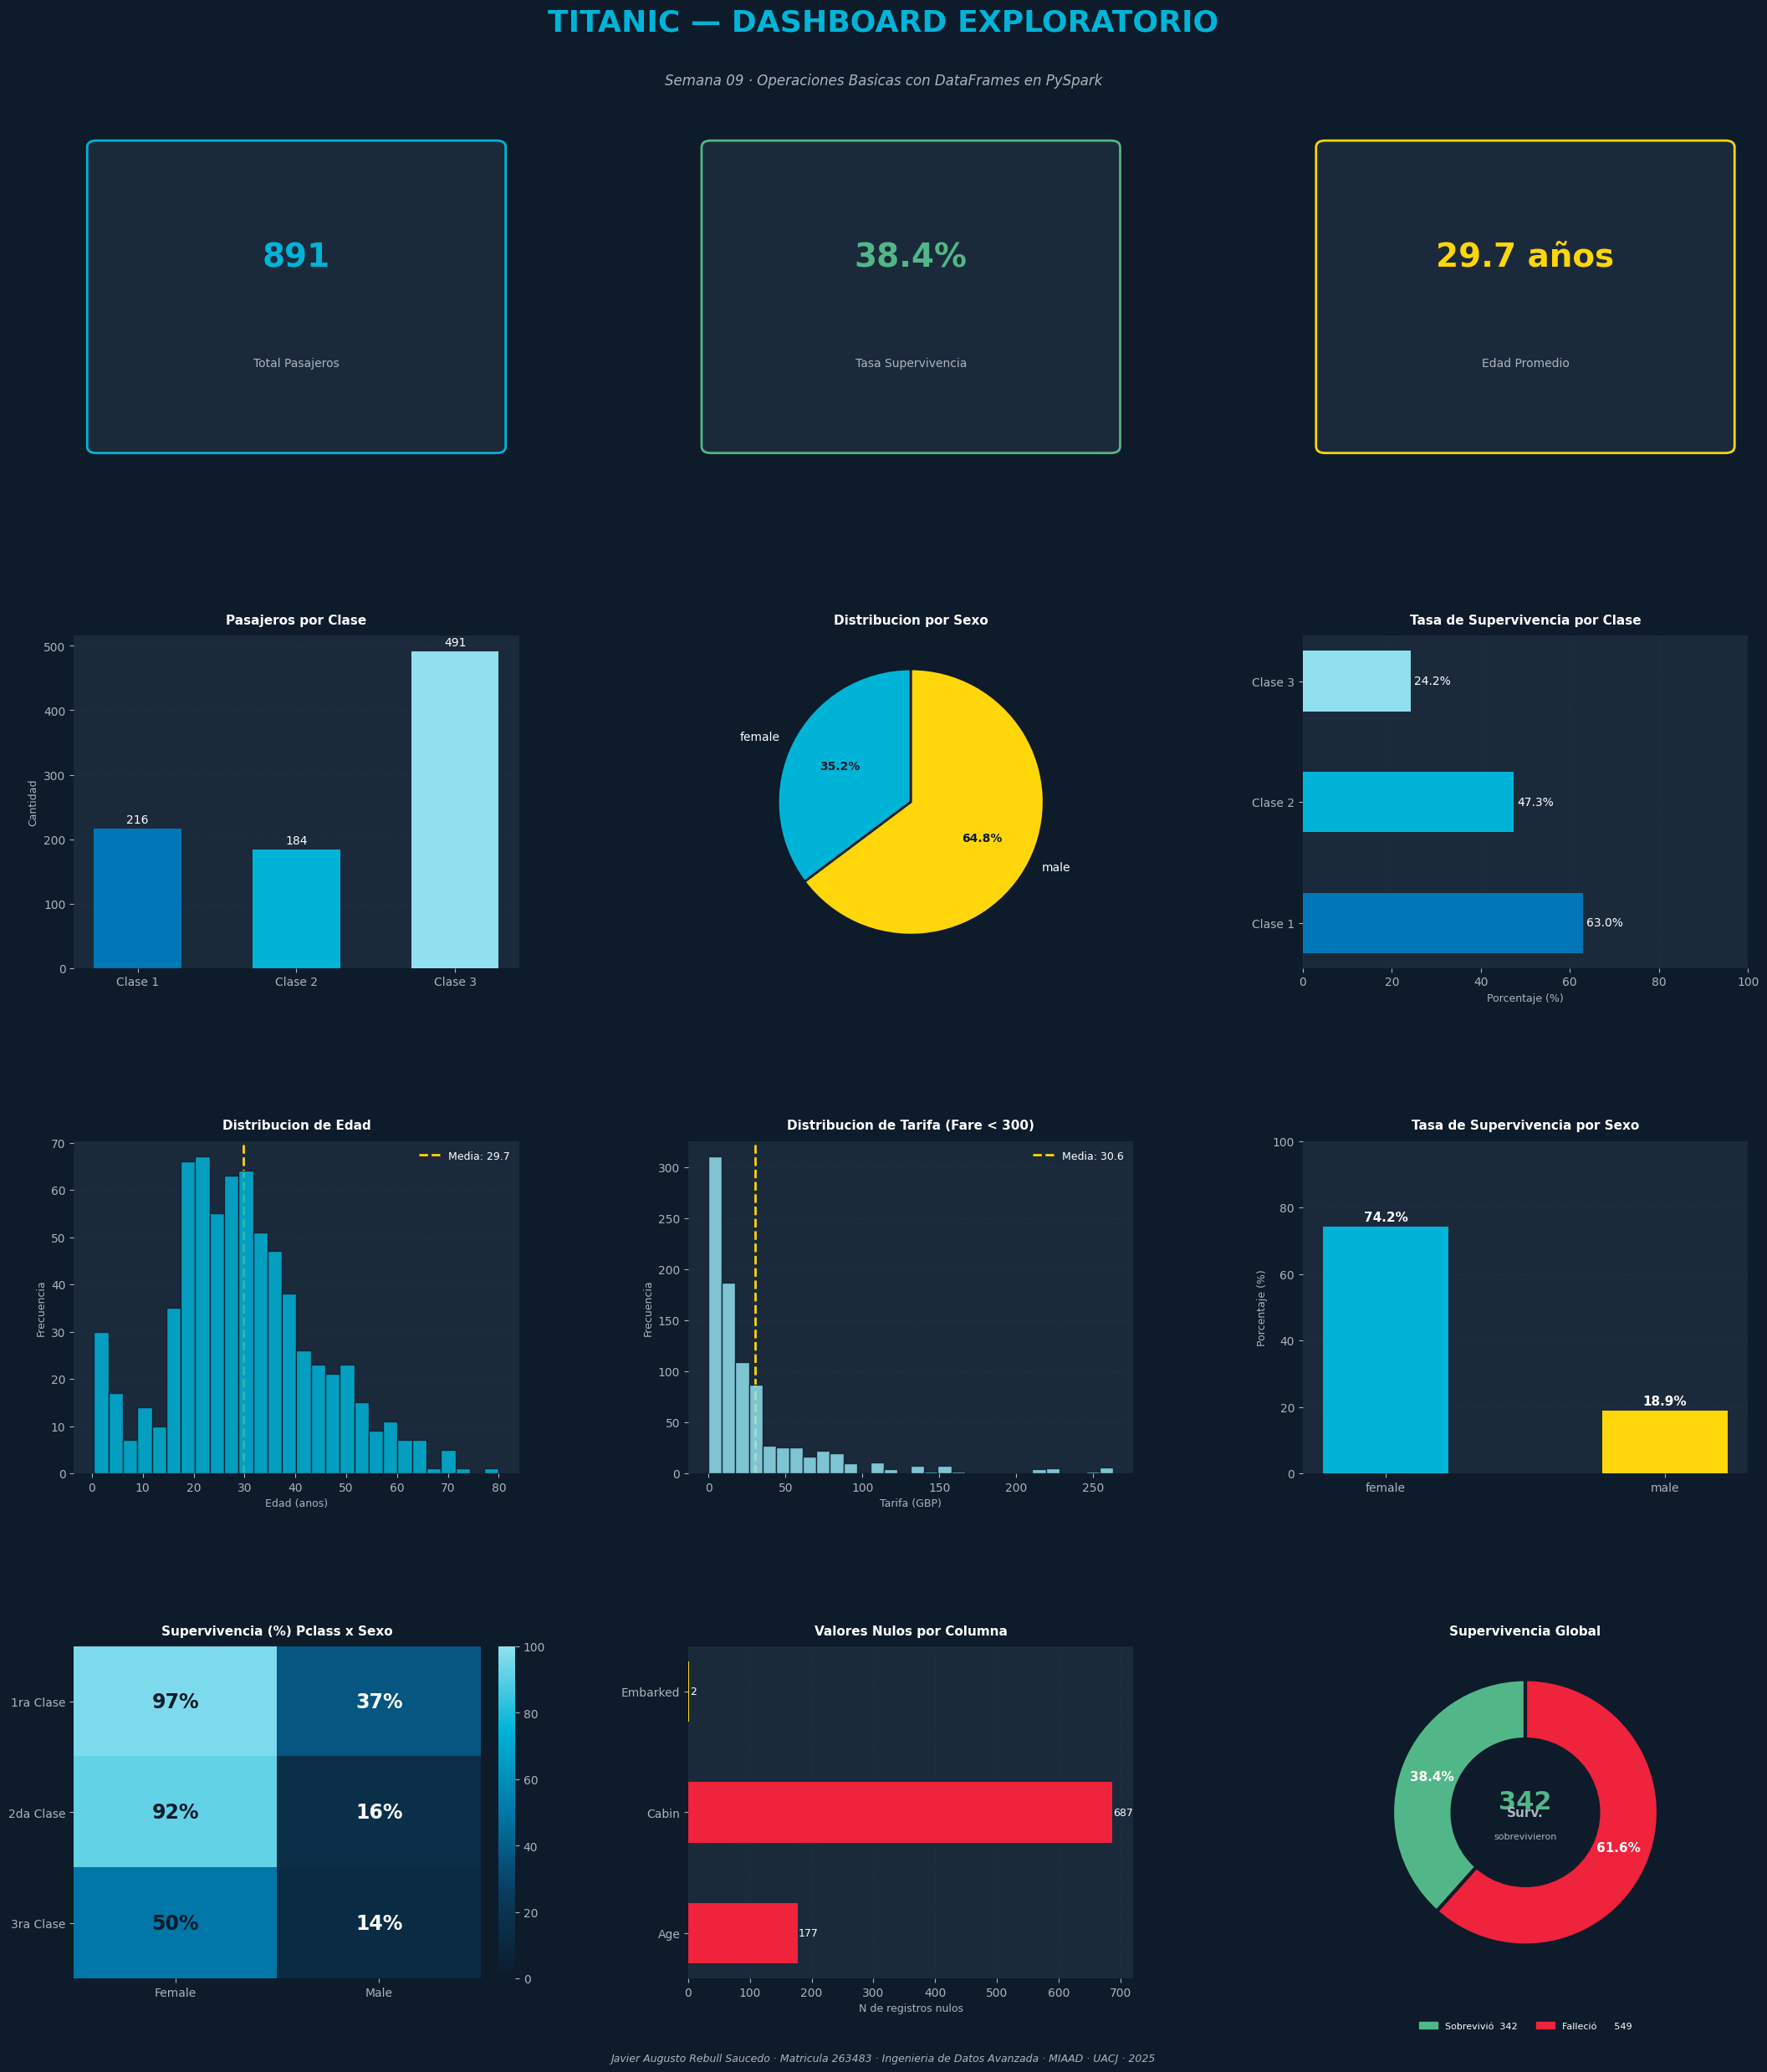

Dashboard guardado como titanic_dashboard.png


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  DASHBOARD FINAL — TITANIC  (matplotlib)
# ══════════════════════════════════════════════════════════════════════════════

# ── Paleta y estilos ──────────────────────────────────────────────────────────
COLOR_BG      = "#0d1b2a"
COLOR_PANEL   = "#1b2a3b"
COLOR_ACCENT1 = "#00b4d8"
COLOR_ACCENT2 = "#90e0ef"
COLOR_GOLD    = "#ffd60a"
COLOR_RED     = "#ef233c"
COLOR_GREEN   = "#52b788"
COLOR_GRAY    = "#adb5bd"
FONT_MAIN     = "DejaVu Sans"

PALETTE_CLASES = ["#0077b6", "#00b4d8", "#90e0ef"]
PALETTE_SEX    = [COLOR_ACCENT1, COLOR_GOLD]

plt.rcParams.update({
    "font.family"       : FONT_MAIN,
    "axes.facecolor"    : COLOR_PANEL,
    "figure.facecolor"  : COLOR_BG,
    "text.color"        : "white",
    "axes.labelcolor"   : COLOR_GRAY,
    "xtick.color"       : COLOR_GRAY,
    "ytick.color"       : COLOR_GRAY,
    "axes.edgecolor"    : COLOR_PANEL,
    "grid.color"        : "#243447",
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.5,
})

# ── Figura principal con GridSpec ─────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor(COLOR_BG)

gs = gridspec.GridSpec(
    4, 3,
    figure=fig,
    hspace=0.52,
    wspace=0.38,
    left=0.06, right=0.97,
    top=0.90, bottom=0.05
)

# ── Titulo principal ──────────────────────────────────────────────────────────
fig.text(
    0.5, 0.95,
    "TITANIC — DASHBOARD EXPLORATORIO",
    ha="center", va="center",
    fontsize=26, fontweight="bold",
    color=COLOR_ACCENT1, fontfamily=FONT_MAIN
)
fig.text(
    0.5, 0.923,
    "Semana 09 · Operaciones Basicas con DataFrames en PySpark",
    ha="center", va="center",
    fontsize=12, color=COLOR_GRAY, fontstyle="italic"
)

# ─── Utilidad: estilizar axes ───────────────────────────────────────────────
def style_ax(ax, title, ylabel="", xlabel="", grid_axis="y"):
    ax.set_facecolor(COLOR_PANEL)
    ax.set_title(title, color="white", fontsize=11,
                 fontweight="bold", pad=10)
    if ylabel:
        ax.set_ylabel(ylabel, color=COLOR_GRAY, fontsize=9)
    if xlabel:
        ax.set_xlabel(xlabel, color=COLOR_GRAY, fontsize=9)
    ax.grid(axis=grid_axis)
    for spine in ax.spines.values():
        spine.set_visible(False)

# ═══════════════════════════════════════════════════════════════════
#  FILA 1 — KPIs  (3 tarjetas)
# ═══════════════════════════════════════════════════════════════════
kpi_data = [
    ("Total Pasajeros",    f"{total_filas:,}",         COLOR_ACCENT1),
    ("Tasa Supervivencia", f"{surv_dict.get(1,0)/total_filas*100:.1f}%", COLOR_GREEN),
    ("Edad Promedio",      f"{np.mean(edades):.1f} años",               COLOR_GOLD),
]

for idx, (label, value, color) in enumerate(kpi_data):
    ax_kpi = fig.add_subplot(gs[0, idx])
    ax_kpi.set_facecolor(COLOR_PANEL)
    ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
    ax_kpi.axis("off")
    # Marco de color
    rect = mpatches.FancyBboxPatch(
        (0.05, 0.05), 0.9, 0.9,
        boxstyle="round,pad=0.02",
        linewidth=2, edgecolor=color,
        facecolor=COLOR_PANEL
    )
    ax_kpi.add_patch(rect)
    ax_kpi.text(0.5, 0.62, value,
                ha="center", va="center",
                fontsize=28, fontweight="bold", color=color)
    ax_kpi.text(0.5, 0.30, label,
                ha="center", va="center",
                fontsize=10, color=COLOR_GRAY)

# ═══════════════════════════════════════════════════════════════════
#  FILA 2 — Barras: distribucion clase | Pie: sexo | Barras: surv. clase
# ═══════════════════════════════════════════════════════════════════

# G1: Pasajeros por Clase
ax1 = fig.add_subplot(gs[1, 0])
bars = ax1.bar(clases, clase_cnt, color=PALETTE_CLASES, width=0.55, zorder=3)
for bar, v in zip(bars, clase_cnt):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(v), ha="center", va="bottom", color="white", fontsize=10)
style_ax(ax1, "Pasajeros por Clase", ylabel="Cantidad")

# G2: Distribucion por Sexo (pie)
ax2 = fig.add_subplot(gs[1, 1])
wedge_props = {"linewidth": 2, "edgecolor": COLOR_BG}
wedges, texts, autotexts = ax2.pie(
    sex_cnt,
    labels=sexos,
    autopct="%1.1f%%",
    colors=PALETTE_SEX,
    startangle=90,
    wedgeprops=wedge_props,
    textprops={"color": "white", "fontsize": 10}
)
for at in autotexts:
    at.set_color(COLOR_BG)
    at.set_fontweight("bold")
ax2.set_title("Distribucion por Sexo", color="white",
               fontsize=11, fontweight="bold", pad=10)
ax2.set_facecolor(COLOR_PANEL)

# G3: Tasa de supervivencia por Clase
ax3 = fig.add_subplot(gs[1, 2])
bars3 = ax3.barh(clases, surv_por_clase, color=PALETTE_CLASES, height=0.5, zorder=3)
for bar, v in zip(bars3, surv_por_clase):
    ax3.text(v + 0.8, bar.get_y() + bar.get_height()/2,
             f"{v}%", va="center", color="white", fontsize=10)
ax3.set_xlim(0, 100)
style_ax(ax3, "Tasa de Supervivencia por Clase",
         xlabel="Porcentaje (%)", grid_axis="x")

# ═══════════════════════════════════════════════════════════════════
#  FILA 3 — Histograma Edad | Histograma Tarifa | Surv. por Sexo
# ═══════════════════════════════════════════════════════════════════

# G4: Distribucion de Edad
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(edades, bins=28, color=COLOR_ACCENT1, alpha=0.85,
         edgecolor=COLOR_BG, zorder=3)
ax4.axvline(np.mean(edades), color=COLOR_GOLD, linewidth=2,
             linestyle="--", label=f"Media: {np.mean(edades):.1f}")
ax4.legend(fontsize=9, framealpha=0, labelcolor="white")
style_ax(ax4, "Distribucion de Edad",
         xlabel="Edad (anos)", ylabel="Frecuencia")

# G5: Distribucion de Tarifa
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(tarifas, bins=30, color=COLOR_ACCENT2, alpha=0.85,
         edgecolor=COLOR_BG, zorder=3)
ax5.axvline(np.mean(tarifas), color=COLOR_GOLD, linewidth=2,
             linestyle="--", label=f"Media: {np.mean(tarifas):.1f}")
ax5.legend(fontsize=9, framealpha=0, labelcolor="white")
style_ax(ax5, "Distribucion de Tarifa (Fare < 300)",
         xlabel="Tarifa (GBP)", ylabel="Frecuencia")

# G6: Tasa de supervivencia por Sexo
ax6 = fig.add_subplot(gs[2, 2])
colores_sex = [COLOR_ACCENT1 if s == "female" else COLOR_GOLD
               for s in surv_por_sexo_labels]
bars6 = ax6.bar(surv_por_sexo_labels, surv_por_sexo_vals,
                color=colores_sex, width=0.45, zorder=3)
for bar, v in zip(bars6, surv_por_sexo_vals):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{v}%", ha="center", va="bottom", color="white", fontsize=11,
             fontweight="bold")
ax6.set_ylim(0, 100)
style_ax(ax6, "Tasa de Supervivencia por Sexo",
         ylabel="Porcentaje (%)")

# ═══════════════════════════════════════════════════════════════════
#  FILA 4 — Heatmap Surv. Pclass x Sex | Nulos | Supervivencia global
# ═══════════════════════════════════════════════════════════════════

# G7: Heatmap supervivencia Pclass x Sex
ax7 = fig.add_subplot(gs[3, 0])
ax7.set_facecolor(COLOR_PANEL)

heat_data = {}
for row in surv_psex:
    heat_data[(row['Pclass'], row['Sex'])] = row['pct']

heat_matrix = []
sex_order = ["female", "male"]
for p in [1, 2, 3]:
    heat_matrix.append([heat_data.get((p, s), 0) for s in sex_order])

heat_arr = np.array(heat_matrix)

# Colormap personalizado: del azul oscuro del dashboard hasta el cian del acento
from matplotlib.colors import LinearSegmentedColormap
cmap_dash = LinearSegmentedColormap.from_list(
    "dash", ["#0d1b2a", "#0a3a5c", "#0077a8", "#00b4d8", "#90e0ef"], N=256
)

im = ax7.imshow(heat_arr, cmap=cmap_dash, aspect="auto", vmin=0, vmax=100)

ax7.set_xticks([0, 1])
ax7.set_xticklabels(["Female", "Male"], color=COLOR_GRAY, fontsize=10)
ax7.set_yticks([0, 1, 2])
ax7.set_yticklabels(["1ra Clase", "2da Clase", "3ra Clase"], color=COLOR_GRAY, fontsize=10)

for i in range(3):
    for j in range(2):
        val = heat_arr[i, j]
        # Valores bajos (<45) texto claro, valores altos texto oscuro
        txt_color = "#0d1b2a" if val > 45 else "#ffffff"
        ax7.text(j, i, f"{val:.0f}%",
                 ha="center", va="center",
                 color=txt_color,
                 fontsize=17, fontweight="bold")

cbar = plt.colorbar(im, ax=ax7, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color=COLOR_GRAY)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=COLOR_GRAY)
cbar.outline.set_visible(False)

ax7.set_title("Supervivencia (%) Pclass x Sexo",
              color="white", fontsize=11, fontweight="bold", pad=10)
for spine in ax7.spines.values():
    spine.set_visible(False)

# G8: Nulos por columna
ax8 = fig.add_subplot(gs[3, 1])
colores_nulos = [COLOR_RED if v > 100 else COLOR_GOLD for v in nulos_vals]
bars8 = ax8.barh(nulos_labels, nulos_vals, color=colores_nulos,
                  height=0.5, zorder=3)
for bar, v in zip(bars8, nulos_vals):
    ax8.text(v + 1, bar.get_y() + bar.get_height()/2,
             str(v), va="center", color="white", fontsize=9)
style_ax(ax8, "Valores Nulos por Columna",
         xlabel="N de registros nulos", grid_axis="x")

# G9: Supervivencia global (dona)
ax9 = fig.add_subplot(gs[3, 2])
ax9.set_facecolor(COLOR_PANEL)

no_surv = surv_dict.get(0, 0)
si_surv = surv_dict.get(1, 0)

wedges9, texts9, autotexts9 = ax9.pie(
    [si_surv, no_surv],
    labels=None,
    autopct="%1.1f%%",
    colors=[COLOR_GREEN, COLOR_RED],
    startangle=90,
    wedgeprops={"linewidth": 3, "edgecolor": COLOR_BG, "width": 0.45},
    pctdistance=0.75,
    textprops={"color": "white", "fontsize": 11, "fontweight": "bold"}
)

# Etiqueta central
ax9.text(0, 0.08, f"{si_surv}", ha="center", va="center",
         fontsize=22, fontweight="bold", color=COLOR_GREEN)
ax9.text(0, -0.18, "sobrevivieron", ha="center", va="center",
         fontsize=8, color=COLOR_GRAY)

# Leyenda manual debajo
ax9.legend(
    handles=[
        mpatches.Patch(color=COLOR_GREEN, label=f"Sobrevivió  {si_surv}"),
        mpatches.Patch(color=COLOR_RED,   label=f"Falleció      {no_surv}"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    fontsize=8,
    frameon=False,
    labelcolor="white"
)

ax9.set_title("Supervivencia Global", color="white",
              fontsize=11, fontweight="bold", pad=12)
# Etiqueta central
ax9.text(0, 0, "Surv.", ha="center", va="center",
          fontsize=11, color=COLOR_GRAY, fontweight="bold")
ax9.set_title("Supervivencia Global", color="white",
               fontsize=11, fontweight="bold", pad=10)

# ── Pie de figura ─────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.012,
    "Javier Augusto Rebull Saucedo · Matricula 263483 · "
    "Ingenieria de Datos Avanzada · MIAAD · UACJ · 2025",
    ha="center", fontsize=9, color=COLOR_GRAY, fontstyle="italic"
)

plt.savefig("titanic_dashboard.png", dpi=180, bbox_inches="tight",
            facecolor=COLOR_BG)
plt.show()
print("Dashboard guardado como titanic_dashboard.png")

---

## Bloque 10: Conclusiones y Reflexiones Personales

Trabajar con PySpark DataFrames en este dataset fue un ejercicio que conectó directamente con mi experiencia profesional.
En Citi Banamex administré bases de datos de millones de clientes en SAS, y en Santander US trabajo diariamente con pipelines
de datos estructurados — pero siempre dentro del paradigma relacional. Este ejercicio me hizo ver que la brecha entre SQL y
PySpark es mucho más pequeña de lo que imaginaba: `groupBy`, `filter`, `select` son conceptos que ya vivo, pero ahora
distribuidos y optimizados por el Catalyst Optimizer sin que yo tenga que pensar en el plan de ejecución.

Lo que más me impactó fue comprobar que `printSchema()` y `describe()` son suficientes para hacer un data profiling inicial
de calidad en segundos sobre un dataset completo. En entornos bancarios ese mismo proceso puede tomar horas con herramientas
legacy. La inmutabilidad de los DataFrames también cambia la mentalidad: ya no "modifico" datos, genero transformaciones —
lo que hace el linaje de datos algo natural, no un proceso adicional.

El análisis de valores nulos fue revelador: la columna `Cabin` tiene casi 77% de datos faltantes, algo que en un contexto
de banca significaría una alerta inmediata de calidad de datos. Ver eso en segundos con `isNull()` confirma por qué PySpark
es la base de los pipelines modernos de ingeniería de datos.

---

<table width="100%" style="border-collapse:collapse; background:#f8f9fa; border-radius:10px; overflow:hidden; border: 1px solid #dee2e6;">
<tr>
  <td style="border:none; padding:28px 32px; vertical-align:middle;">
    <div style="font-size:11px; color:#0077a8; letter-spacing:3px; margin-bottom:12px;">AUTOR</div>
    <div style="font-size:20px; font-weight:600; color:#0d1b2a; margin-bottom:4px;">Javier Augusto Rebull Saucedo</div>
    <div style="font-size:13px; color:#0077a8; letter-spacing:1px; margin-bottom:16px;">Matrícula 263483</div>
    <hr style="border:none; border-top:1px solid #dee2e6; margin-bottom:14px;">
    <div style="font-size:13px; color:#495057; line-height:2.0;">
      Sr. Associate, Application Development &nbsp;·&nbsp; Banco Santander US<br>
      Maestría en Inteligencia Artificial y Analítica de Datos &nbsp;·&nbsp; UACJ<br>
      Ingeniería de Datos Avanzada &nbsp;·&nbsp; Dr. Vicente García Jiménez &nbsp;·&nbsp; 2026
    </div>
  </td>
  <td style="border:none; padding:0; width:140px; vertical-align:bottom;">
    <img src="https://iili.io/qrfnJLv.jpg"
         style="display:block; width:140px; height:175px;
                object-fit:cover; object-position:top center;" />
  </td>
</tr>
</table>

---
## Bloque 11. Referencias

Armbrust, M., Xin, R. S., Lian, C., Huai, Y., Liu, D., Bradley, J. K., Meng, X., Kaftan, T., Franklin, M. J., Ghodsi, A., & Zaharia, M. (2015). Spark SQL: Relational data processing in Spark. *Proceedings of the 2015 ACM SIGMOD International Conference on Management of Data*, 1383–1394. https://doi.org/10.1145/2723372.2742797

García Jiménez, V. (2025a). *Sesion19PySparkDataframe.ipynb* [Cuaderno de Google Colab]. Ingeniería de Datos Avanzada, Maestría en Inteligencia Artificial y Analítica de Datos, Universidad Autónoma de Ciudad Juárez. https://colab.research.google.com/drive/1IoeHT237ybxUzb9Z6bABvtnetUUkl2ng?usp=sharing

García Jiménez, V. (2025b). *Spark SQL y Dataframes: Introducción breve* [Video]. Ingeniería de Datos Avanzada, Maestría en Inteligencia Artificial y Analítica de Datos, Universidad Autónoma de Ciudad Juárez. https://www.youtube.com/watch?v=mRDDo1fCfYU

Kaggle. (2012). *Titanic — Machine learning from disaster* [Dataset]. https://www.kaggle.com/competitions/titanic

The Apache Software Foundation. (2024). *PySpark documentation: DataFrame* (Versión 3.5). https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/dataframe.html

Zaharia, M., Xin, R. S., Wendell, P., Das, T., Armbrust, M., Dave, A., Meng, X., Rosen, J., Franklin, M. J., Ghodsi, A., Gonzalez, J., Shenker, S., & Stoica, I. (2016). Apache Spark: A unified engine for big data processing. *Communications of the ACM, 59*(11), 56–65. https://doi.org/10.1145/2934664

In [24]:
# ── Cerrar la SparkSession al finalizar ───────────────────────────────────────
# Buena practica: liberar los recursos del cluster al terminar el notebook
spark.stop()
print("SparkSession cerrada correctamente.")

SparkSession cerrada correctamente.
